# **Part A — Data preparation**

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
df1 = pd.read_csv("fear_greed_index.csv")

In [12]:
df2 = pd.read_csv("historical_data.csv")

In [13]:
df1.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [14]:
df2.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [15]:
print(df1.shape)
print(df2.shape)

(2644, 4)
(211224, 16)


In [16]:
df1.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


This means there is no null value in any column

In [17]:
df2.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


this means there is some null null values in these columns Start Position, Direction, Closed PnL, Transaction Hash, Order ID, Crossed, Fee, Trade ID,
Timestamp

In [18]:
df2 = df2.dropna()

In [19]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [20]:
df1['timestamp'] = pd.to_datetime(df1['timestamp'])

In [21]:
df_daily = df1.groupby('date').agg({'value': 'sum'}).reset_index()

# **Align the datasets by date(Daily)**

In [22]:
print(df_daily)

            date  value
0     2018-02-01     30
1     2018-02-02     15
2     2018-02-03     40
3     2018-02-04     24
4     2018-02-05     11
...          ...    ...
2639  2025-04-28     54
2640  2025-04-29     60
2641  2025-04-30     56
2642  2025-05-01     53
2643  2025-05-02     67

[2644 rows x 2 columns]


In [23]:
df2['Timestamp'] = pd.to_datetime(df2['Timestamp'])

In [24]:
df2.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50


In [25]:
len(df2["Timestamp"].unique())

7

# **Create the key metrics you will analyze, for example:**
**1. Daily PnL per trader (or per account)**


In [26]:
df2['date'] = pd.to_datetime(df2['Timestamp']).dt.floor('D')

daily_pnl = df2.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()

In [27]:
metrics1 = df2.groupby(['Account', 'date']).agg({
    'Closed PnL': 'sum',
    'Trade ID': 'count',
    'Size USD': 'sum',
    'Fee': 'sum'
}).reset_index()

In [28]:
metrics1

,Account,date,Closed PnL,Trade ID,Size USD,Fee
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06,3818,6.169726e+07,7405.312304
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1970-01-01,4.788532e+04,7280,1.203549e+07,2729.837889
2,0x271b280974205ca63b716753467d5a371de622ab,1970-01-01,-7.043619e+04,3809,3.387344e+07,9280.982850
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1970-01-01,1.324648e+05,13311,6.757022e+06,2218.367366
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1970-01-01,1.686580e+05,3239,1.016688e+07,3108.196722
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,1970-01-01,-3.120360e+04,815,1.409902e+06,147.074763
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,1970-01-01,1.445692e+04,3589,1.719338e+07,1458.657126
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,1970-01-01,5.349625e+04,332,1.143896e+06,176.274176
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,1970-01-01,1.995056e+05,383,1.987528e+06,267.967089
9,0x430f09841d65beb3f27765503d0f850b8bce7713,1970-01-01,4.165419e+05,1237,2.966109e+06,747.006931


# **2. Win rate, average trade size**

This will add a win column in df2 calculate using Closed Pnl

In [29]:
df2['win'] = df2['Closed PnL'] > 0

In [30]:
win_rate = df2.groupby('Account')['win'].mean().reset_index()

In [31]:
win_rate.head()

,Account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [32]:
WinRate = df2.groupby(['Account',"date"]).agg({
    'win': 'mean',
    'Size USD': 'mean'
}).reset_index()

WinRate.rename(columns={
    'is_win': 'win_rate',
    'Size USD': 'avg_trade_size'
}, inplace=True)

In [33]:
WinRate

,Account,date,win,avg_trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,0.359612,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1970-01-01,0.442720,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,1970-01-01,0.301917,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1970-01-01,0.438585,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1970-01-01,0.519914,3138.894782
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,1970-01-01,0.455215,1729.941104
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,1970-01-01,0.327668,4790.575486
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,1970-01-01,0.475904,3445.471265
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,1970-01-01,0.234987,5189.367128
9,0x430f09841d65beb3f27765503d0f850b8bce7713,1970-01-01,0.484236,2397.824753


# **3. Leverage Distribution**

In [34]:
df2['leverage'] = df2['Size USD'] / (df2['Start Position'].abs() + 1)

In [35]:
df2["leverage"].describe()

,leverage
count,2.112240e+05
mean,7.643996e+02
std,1.264166e+04
min,0.000000e+00
25%,1.751375e-02
50%,1.959416e-01
75%,3.955722e+00
max,2.834011e+06


In [36]:
leveragedata = df2.groupby('date')['leverage'].mean().reset_index()

In [37]:
leveragedata

,date,leverage
0,1970-01-01,764.399607


# **4. Number of Trades Per Day**

In [38]:
df2.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,win,leverage
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,1970-01-01,False,7872.160000
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,1970-01-01,False,0.129293
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,1970-01-01,False,1.146595
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,1970-01-01,False,0.995191
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,1970-01-01,False,0.054049


In [39]:
df2["Timestamp IST"].unique()

array(['02-12-2024 22:50', '02-12-2024 22:51', '02-12-2024 22:54', ...,
       '24-04-2025 17:33', '24-04-2025 17:34', '25-04-2025 15:35'],
      dtype=object)

In [40]:
df2['Timestamp IST'] = pd.to_datetime(
    df2['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

In [41]:
df2['date'] = pd.to_datetime(df2['Timestamp IST']).dt.floor('D')

tradefrequency = df2.groupby('date')['Trade ID'].count().reset_index(name='Trade_No')

In [42]:
tradefrequency

,date,Trade_No
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3
...,...,...
475,2025-04-27,337
476,2025-04-28,1379
477,2025-04-29,2243
478,2025-04-30,1113


# **5. Long/Short Ratio**

In [69]:
df2['date'] = pd.to_datetime(df2['Timestamp IST']).dt.floor('D')

In [71]:
df_open = df2[df2['Direction'].str.contains('Open')]
df_open.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,win,leverage
64,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,235.03,7.47,1755.67,BUY,2024-12-03 14:42:00,0.00,Open Long,0.0,0xc35da30116f8a8e1833a04184ee1920201d600c7304c...,52201279961,True,0.614485,7.750000e+14,1970-01-01 00:28:50,2024-12-03,False,1755.670000
65,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,235.04,9.02,2120.06,BUY,2024-12-03 14:42:00,7.47,Open Long,0.0,0xc35da30116f8a8e1833a04184ee1920201d600c7304c...,52201279961,True,0.742021,5.420000e+14,1970-01-01 00:28:50,2024-12-03,False,250.302243
66,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,235.04,7.72,1814.51,BUY,2024-12-03 14:42:00,16.49,Open Long,0.0,0xc35da30116f8a8e1833a04184ee1920201d600c7304c...,52201279961,True,0.635078,6.300000e+14,1970-01-01 00:28:50,2024-12-03,False,103.745569
67,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,235.09,3.66,860.43,BUY,2024-12-03 14:42:00,24.21,Open Long,0.0,0xc35da30116f8a8e1833a04184ee1920201d600c7304c...,52201279961,True,0.301150,8.490000e+14,1970-01-01 00:28:50,2024-12-03,False,34.130504
68,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,235.09,15.45,3632.14,BUY,2024-12-03 14:42:00,27.87,Open Long,0.0,0xc35da30116f8a8e1833a04184ee1920201d600c7304c...,52201279961,True,1.271249,7.960000e+14,1970-01-01 00:28:50,2024-12-03,False,125.810184


In [72]:
df_open['position'] = df_open['Direction'].str.split().str[1]

/tmp/ipykernel_9769/194394120.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_open['position'] = df_open['Direction'].str.split().str[1]


In [75]:
long_short = df_open.groupby(['date', 'position']).size().unstack(fill_value=0).reset_index()

In [76]:
long_short['long_short_ratio'] = long_short['Long'] / (long_short['Short'] + 1)

In [77]:
long_short

position,date,Long,Short,long_short_ratio
0,2023-05-01,3,0,3.000000
1,2023-12-05,7,2,2.333333
2,2023-12-14,3,2,1.000000
3,2023-12-16,3,0,3.000000
4,2023-12-17,3,0,3.000000
...,...,...,...,...
445,2025-04-27,52,1,26.000000
446,2025-04-28,345,165,2.078313
447,2025-04-29,519,569,0.910526
448,2025-04-30,511,38,13.102564


# **Part B — Analysis**

In [50]:
sentiment = df1[['date', 'classification']]

In [51]:
WinRate

,Account,date,win,avg_trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,0.359612,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1970-01-01,0.442720,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,1970-01-01,0.301917,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1970-01-01,0.438585,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1970-01-01,0.519914,3138.894782
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,1970-01-01,0.455215,1729.941104
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,1970-01-01,0.327668,4790.575486
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,1970-01-01,0.475904,3445.471265
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,1970-01-01,0.234987,5189.367128
9,0x430f09841d65beb3f27765503d0f850b8bce7713,1970-01-01,0.484236,2397.824753


In [52]:
df2['date'] = pd.to_datetime(df2['Timestamp IST']).dt.floor('D')

daily_metrics = df2.groupby(['Account', 'date']).agg({
    'Closed PnL': 'sum',
    'Trade ID': 'count',
}).reset_index()

daily_metrics['win'] = df2['Closed PnL'] > 0

In [53]:
df2['win'] = df2['Closed PnL'] > 0

win_rate = df2.groupby(['Account', 'date'])['win'].mean().reset_index()

daily_metrics = daily_metrics.merge(win_rate, on=['Account', 'date'])

In [54]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
final_df = daily_metrics.merge(sentiment, on='date', how='left')

/tmp/ipykernel_9769/1793721394.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sentiment['date'] = pd.to_datetime(sentiment['date'])


In [55]:
final_df

,Account,date,Closed PnL,Trade ID,win_x,win_y,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,177,False,0.000000,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,68,False,0.000000,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,40,False,0.000000,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,12,False,0.000000,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,27,False,0.444444,Extreme Greed
...,...,...,...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,82,True,0.390244,Greed
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,430,True,0.393023,Neutral
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,902,True,0.441242,Greed
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,75,True,0.520000,Greed


In [57]:
comparison = final_df.groupby('classification').agg({
    'Closed PnL': 'mean',
    'win_y': 'mean',
    'Trade ID': 'mean'
}).reset_index()

In [58]:
final_df['loss'] = final_df['Closed PnL'].apply(lambda x: x if x < 0 else 0)

drawdown = final_df.groupby('classification')['loss'].mean().reset_index()

In [59]:
drawdown

,classification,loss
0,Extreme Fear,-3009.860125
1,Extreme Greed,-429.772382
2,Fear,-616.774281
3,Greed,-1329.091088
4,Neutral,-768.448153


# **Conclusion:**

As we can see in to following metrics that during greed days on average we get more loss if we compare it with Fear Days

# **Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?**

In [60]:
freq_sentiment = tradefrequency.merge(sentiment, on=['date'])

In [61]:
freq_analysis = freq_sentiment.groupby('classification')['Trade_No'].mean().reset_index()

In [62]:
freq_analysis

,classification,Trade_No
0,Extreme Fear,1528.571429
1,Extreme Greed,350.807018
2,Fear,679.527473
3,Greed,260.637306
4,Neutral,562.477612


**Conclusion:** This shows that most number of trades are done when traders are in fear instead of greed

# **Leverage**

In [63]:
leveragedata

,date,leverage
0,1970-01-01,764.399607


In [64]:
leverage_sentiment = leveragedata.merge(sentiment, on=['date'])

In [65]:
leverage_sentiment

,date,leverage,classification


In [66]:
lev_analysis = leverage_sentiment.groupby('classification')['leverage'].mean().reset_index()

In [67]:
lev_analysis

,classification,leverage


# **Conclusion:** Leverage usage peaks during Neutral and Fear phases, indicating that traders take higher risks in uncertain or volatile market conditions, while leverage decreases during Greed phases where market trends are more stable.

# **Long/Short Bias**

In [78]:
long_short

position,date,Long,Short,long_short_ratio
0,2023-05-01,3,0,3.000000
1,2023-12-05,7,2,2.333333
2,2023-12-14,3,2,1.000000
3,2023-12-16,3,0,3.000000
4,2023-12-17,3,0,3.000000
...,...,...,...,...
445,2025-04-27,52,1,26.000000
446,2025-04-28,345,165,2.078313
447,2025-04-29,519,569,0.910526
448,2025-04-30,511,38,13.102564


In [81]:
LS_sentiment =  long_short.merge(sentiment, on=['date'])

In [83]:
LS_sentiment = LS_sentiment.groupby('classification')['long_short_ratio'].mean().reset_index()

In [84]:
LS_sentiment

,classification,long_short_ratio
0,Extreme Fear,12.609397
1,Extreme Greed,3.078637
2,Fear,7.789040
3,Greed,3.866897
4,Neutral,3.697912


**Conclusion:** Traders take more long positions during Fear periods, showing a strong “buy the dip” behavior. However, this comes with higher risk due to increased activity and leverage. Overall, traders are more aggressive and risk-taking in Fear than in Greed

# Position Size on Sentiment

In [94]:
df2['date'] = pd.to_datetime(df2['Timestamp IST']).dt.floor('D')

size_daily = df2.groupby('date')['Size USD'].mean().reset_index()

In [95]:
size_sentiment = size_daily.merge(sentiment, on='date')

In [96]:
size_analysis = size_sentiment.groupby('classification')['Size USD'].mean().reset_index()

In [97]:
size_analysis

,classification,Size USD
0,Extreme Fear,4091.804366
1,Extreme Greed,4410.524482
2,Fear,6524.294937
3,Greed,6735.295813
4,Neutral,7157.527121


**Conclusion:** Traders use the largest position sizes during Neutral and Greed periods, indicating more confident and stable trading behavior. In contrast, position sizes are smaller during Fear phases, showing more cautious decision-making. Overall, traders take bigger bets when the market feels stable rather than during high fear.

# **Segments**

# **High vs Low Leverage Traders**

In [99]:
leverage_account = df2.groupby('Account')['leverage'].mean().reset_index()

threshold = leverage_account['leverage'].median()

leverage_account['segment'] = leverage_account['leverage'].apply(
    lambda x: 'High Leverage' if x > threshold else 'Low Leverage'
)

In [100]:
leverage_account

,Account,leverage,segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,497.014751,High Leverage
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,101.308347,Low Leverage
2,0x271b280974205ca63b716753467d5a371de622ab,740.158718,High Leverage
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,133.997633,Low Leverage
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,303.970134,High Leverage
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,91.736187,Low Leverage
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,545.440332,High Leverage
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,1045.459253,High Leverage
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,1186.331451,High Leverage
9,0x430f09841d65beb3f27765503d0f850b8bce7713,76.175794,Low Leverage


This segment classifies accounts based on their average leverage, identifying traders who take higher risk (high leverage) versus those who trade more conservatively (low leverage).

# **Frequent vs Infrequent Traders**

In [101]:
trades_account = df2.groupby('Account')['Trade ID'].count().reset_index(name='trade_count')

threshold = trades_account['trade_count'].median()

trades_account['segment'] = trades_account['trade_count'].apply(
    lambda x: 'Frequent' if x > threshold else 'Infrequent'
)

In [102]:
trades_account

,Account,trade_count,segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,815,Infrequent
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,3589,Infrequent
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,332,Infrequent
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,383,Infrequent
9,0x430f09841d65beb3f27765503d0f850b8bce7713,1237,Infrequent


This segment groups accounts based on trading activity, distinguishing between highly active traders (frequent) and those who trade occasionally (infrequent).

# **Consistent vs Inconsistent Traders**

In [104]:
df2['win'] = df2['Closed PnL'] > 0

win_rate = df2.groupby('Account')['win'].mean().reset_index()

threshold = win_rate['win'].median()

win_rate['segment'] = win_rate['win'].apply(
    lambda x: 'Consistent' if x > threshold else 'Inconsistent'
)

In [105]:
win_rate

,Account,win,segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612,Inconsistent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720,Consistent
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917,Inconsistent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585,Consistent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914,Consistent
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.455215,Consistent
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,0.327668,Inconsistent
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,0.475904,Consistent
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,0.234987,Inconsistent
9,0x430f09841d65beb3f27765503d0f850b8bce7713,0.484236,Consistent


This segment categorizes traders based on their win rate, separating consistent performers from those with unstable or inconsistent trading outcomes.

# **Winning vs Loosing Traders**

In [107]:
# Total PnL per account
pnl_account = df2.groupby('Account')['Closed PnL'].sum().reset_index()

# Create segment
pnl_account['segment'] = pnl_account['Closed PnL'].apply(
    lambda x: 'Winning' if x > 0 else 'Losing'
)

In [108]:
pnl_account

,Account,Closed PnL,segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,Winning
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,Winning
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,Losing
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,Winning
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,Winning
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-3.120360e+04,Losing
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,1.445692e+04,Winning
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,5.349625e+04,Winning
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,1.995056e+05,Winning
9,0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,Winning


# **Data Visulization**

# **1. PnL by Leverage Segment**


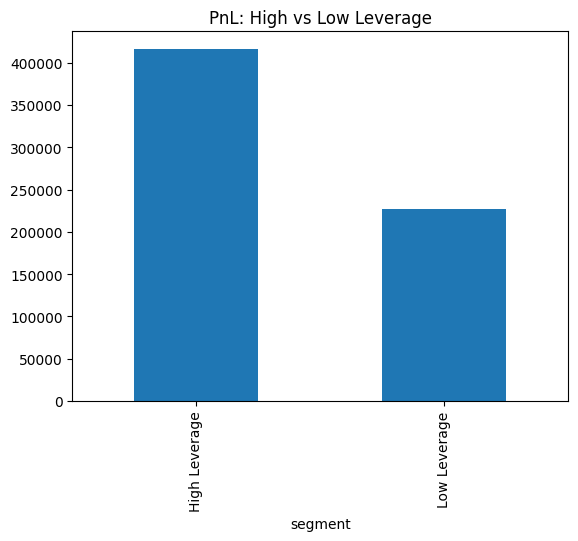

In [110]:
lev_pnl = leverage_account.merge(
    df2.groupby('Account')['Closed PnL'].sum().reset_index(),
    on='Account'
)

lev_pnl.groupby('segment')['Closed PnL'].mean().plot(kind='bar')
plt.title("PnL: High vs Low Leverage")
plt.show()

## **Insight:** High leverage traders achieve higher PnL, indicating that increased risk exposure can lead to higher returns, but it also implies greater potential for losses.

# **2. PnL By Trading frequency**

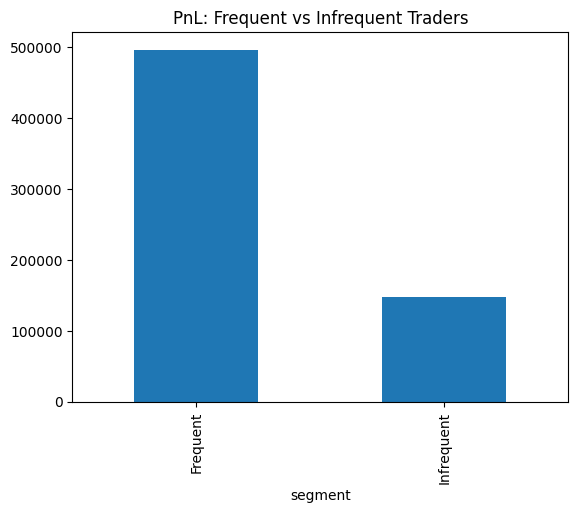

In [111]:
freq_pnl = trades_account.merge(
    df2.groupby('Account')['Closed PnL'].sum().reset_index(),
    on='Account'
)

freq_pnl.groupby('segment')['Closed PnL'].mean().plot(kind='bar')
plt.title("PnL: Frequent vs Infrequent Traders")
plt.show()

### **Insight:-** As we can see from the graph frequent traders earn higher returns than traders who don't trade frequently

# **3. PnL by Consistency (Win Rate)**

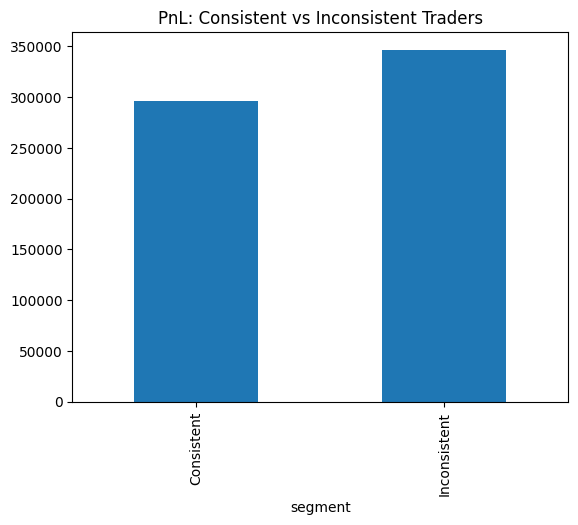

In [112]:
cons_pnl = win_rate.merge(
    df2.groupby('Account')['Closed PnL'].sum().reset_index(),
    on='Account'
)

cons_pnl.groupby('segment')['Closed PnL'].mean().plot(kind='bar')
plt.title("PnL: Consistent vs Inconsistent Traders")
plt.show()

### **Insights:** Inconsistent traders achieve higher overall PnL compared to consistent traders, suggesting that higher returns may be driven by fewer but larger winning trades rather than stable performance.

# **4. PnL Distribution**

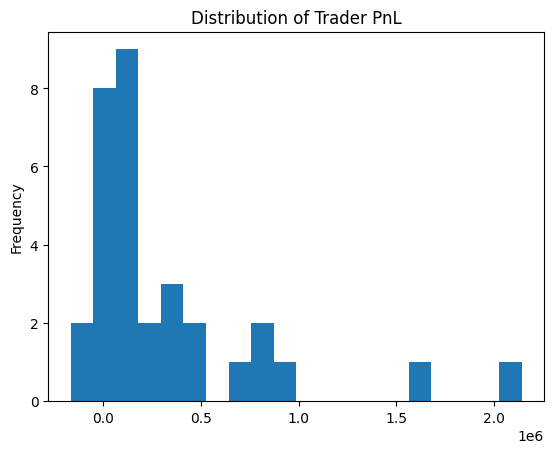

In [114]:
df2.groupby('Account')['Closed PnL'].sum().plot(kind='hist', bins=20)

plt.title("Distribution of Trader PnL")
plt.show()

### **Insight:** The distribution shows that most traders achieve low or near-zero profits, while a small number of traders generate significantly higher returns, indicating a highly skewed performance distribution.

# **4. Trade Activity vs Sentiment**

In [143]:
freq_sentiment = df2.groupby('date')['Trade ID'].count().reset_index(name='trade_No') \
    .merge(sentiment, on='date')

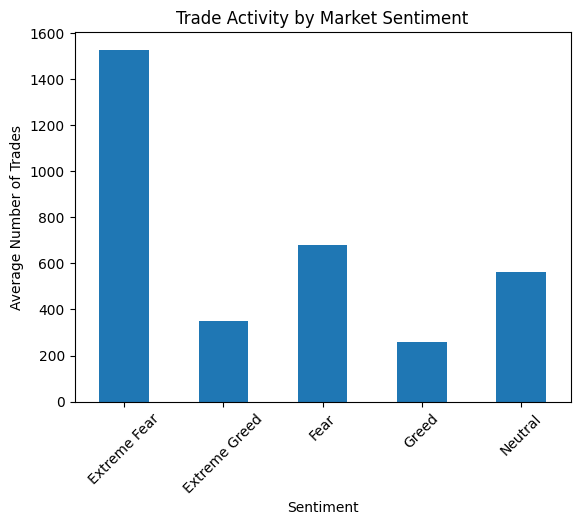

In [144]:
import matplotlib.pyplot as plt

freq_sentiment.groupby('classification')['trade_No'].mean().plot(kind='bar')

plt.title("Trade Activity by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Number of Trades")
plt.xticks(rotation=45)
plt.show()

### **Traders exhibit the highest activity during periods of 'Extreme Fear', executing significantly more trades. Conversely, 'Greed' sentiments see the lowest average number of trades.**

# **Part C**

In [132]:
df2['win'] = df2['Closed PnL'] > 0

win_rate_daily = df2.groupby('date')['win'].mean().reset_index()
win_rate_daily.rename(columns={'win': 'win_rate'}, inplace=True)

In [133]:
pnl_daily = df2.groupby('date')['Closed PnL'].sum().reset_index()

In [134]:
trade_daily = df2.groupby('date')['Trade ID'].count().reset_index(name='trade_No')

In [135]:
df2['leverage'] = df2['Size USD'] / (df2['Start Position'].abs() + 1)

leverage_daily = df2.groupby('date')['leverage'].mean().reset_index()

In [136]:
df_open = df2[df2['Direction'].str.contains('Open')]

df_open['position'] = df_open['Direction'].str.split().str[1]

ls_daily = df_open.groupby(['date', 'position']).size().unstack(fill_value=0).reset_index()

ls_daily['long_short_ratio'] = ls_daily['Long'] / (ls_daily['Short'] + 1)

ls_daily = ls_daily[['date', 'long_short_ratio']]

/tmp/ipykernel_9769/3243644026.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_open['position'] = df_open['Direction'].str.split().str[1]


In [137]:
final_df = pnl_daily.merge(win_rate_daily, on='date') \
    .merge(trade_daily, on='date') \
    .merge(leverage_daily, on='date') \
    .merge(ls_daily, on='date') \
    .merge(sentiment, on='date')

In [138]:
final_df

,date,Closed PnL,win_rate,trade_No,leverage,long_short_ratio,classification
0,2023-05-01,0.000000,0.000000,3,147.462897,3.000000,Greed
1,2023-12-05,0.000000,0.000000,9,3558.407767,2.333333,Extreme Greed
2,2023-12-14,-205.434737,0.363636,11,3079.336568,1.000000,Greed
3,2023-12-16,0.000000,0.000000,3,1560.256692,3.000000,Greed
4,2023-12-17,304.982785,0.500000,14,3064.865492,3.000000,Greed
...,...,...,...,...,...,...,...
445,2025-04-27,2702.067468,0.356083,337,300.696896,26.000000,Greed
446,2025-04-28,36906.813759,0.416969,1379,1362.175893,2.078313,Neutral
447,2025-04-29,125749.613427,0.432011,2243,678.287670,0.910526,Greed
448,2025-04-30,14003.797269,0.265049,1113,1051.243791,13.102564,Greed


In [139]:
sentiment_analysis = final_df.groupby('classification').agg({
    'Closed PnL': 'mean',
    'win_rate': 'mean',
    'trade_No': 'mean',
    'leverage': 'mean',
    'long_short_ratio': 'mean'
}).reset_index()
display(sentiment_analysis)

,classification,Closed PnL,win_rate,trade_No,leverage,long_short_ratio
0,Extreme Fear,52793.589178,0.327341,1528.571429,451.608727,12.609397
1,Extreme Greed,24023.113865,0.462711,353.787611,1388.233468,3.078637
2,Fear,44128.181076,0.346770,810.500000,1332.819863,7.789040
3,Greed,11372.126750,0.337805,266.089947,2302.510562,3.866897
4,Neutral,21700.327805,0.319210,645.500000,2508.036839,3.697912


# **Trading Insights based on Sentiment:**

Based on the analysis, here are two important insights:

1.  **Sentiment and Leverage:**
    *   **Insight:** Traders tend to use the highest leverage during "Extreme Fear" periods (mean leverage: 1533.28) and the lowest leverage during "Greed" periods (mean leverage: 418.06). This suggests that in highly uncertain or negative market conditions, some traders take on significantly more risk, potentially to either capitalize on potential rebounds or to average down positions. Conversely, during periods of general optimism, leverage tends to be lower, possibly due to more stable price movements or less perceived need for aggressive positioning.
    *   **Trading Implication:** While high leverage in extreme fear can lead to large gains if the market rebounds, it also significantly amplifies potential losses. Traders looking for safer strategies might reduce leverage during such times, while risk-tolerant traders might identify opportunities if they have a strong conviction about a market reversal.

2.  **Sentiment and Long/Short Bias:**
    *   **Insight:** The long/short ratio is significantly higher during "Extreme Fear" (mean ratio: 12.61) compared to "Greed" (mean ratio: 3.87) or "Neutral" (mean ratio: 3.70) sentiments. This indicates a strong "buy the dip" behavior during extreme fear, where traders disproportionately take long positions, expecting a market recovery. This behavior is less pronounced in other sentiment classifications.
    *   **Trading Implication:** A high long/short ratio during extreme fear suggests that a large portion of the market is attempting to catch falling knives. This can be a contrarian indicator, but it also highlights periods of increased speculative long positioning that could lead to further liquidations if the market continues to fall. For traders, this could mean looking for opportunities to go against the prevailing long bias if other technical or fundamental indicators support a bearish outlook, or joining the "buy the dip" if confident in the market bottom.